In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv', parse_dates=['order_date'])
tickets = pd.read_csv('support_tickets.csv', parse_dates=['ticket_date'])
web = pd.read_csv('web_events_snapshot.csv')
interventions = pd.read_csv('intervention_history.csv')
churn = pd.read_csv('churn_labels.csv')

In [ ]:
SNAPSHOT_DATE = pd.Timestamp('2025-09-30')

orders = orders[orders['order_date'] <= SNAPSHOT_DATE]

In [ ]:
orders = orders[~orders['order_id'].str.contains('_DUP', na=False)]

In [ ]:
recency = orders.groupby('customer_id')['order_date'].max().reset_index()

recency['recency_days'] = (
    SNAPSHOT_DATE - recency['order_date']
).dt.days

recency = recency[['customer_id', 'recency_days']]

In [ ]:
frequency = orders.groupby('customer_id')['order_id'] \
                  .nunique() \
                  .reset_index()

frequency.columns = ['customer_id', 'frequency']

In [ ]:
monetary = orders.groupby('customer_id')['gross_amount'] \
                 .sum() \
                 .reset_index()

monetary.columns = ['customer_id', 'monetary']

In [ ]:
rfm = recency.merge(frequency, on='customer_id', how='left')
rfm = rfm.merge(monetary, on='customer_id', how='left')

In [ ]:
ticket_features = tickets.groupby('customer_id').agg({
    'ticket_id': 'count',
    'sentiment_score': 'mean',
    'resolution_hours': 'mean',
    'reopened': 'sum'
}).reset_index()

ticket_features.columns = [
    'customer_id',
    'ticket_count',
    'avg_sentiment',
    'avg_resolution_hours',
    'reopened_tickets'
]

In [ ]:
return_rate = orders.groupby('customer_id')['returned'] \
                    .mean() \
                    .reset_index()

return_rate.columns = ['customer_id', 'return_rate']

In [ ]:
discount_usage = orders.groupby('customer_id')['discount_pct'] \
                       .mean() \
                       .reset_index()

discount_usage.columns = ['customer_id', 'avg_discount_pct']

In [ ]:
category_diversity = orders.groupby('customer_id')['category'] \
                           .nunique() \
                           .reset_index()

category_diversity.columns = [
    'customer_id',
    'category_diversity'
]

In [ ]:
web_features = web[[
    'customer_id',
    'sessions_30d',
    'product_views_30d',
    'cart_adds_30d',
    'wishlist_adds_30d',
    'abandoned_carts_30d',
    'campaign_clicks_30d',
    'last_visit_days_ago'
]]

In [ ]:
campaign_features = interventions[[
    'customer_id',
    'last_campaign_received',
    'last_campaign_cost',
    'manual_priority_bucket'
]]

In [ ]:
segments_df = rfm.copy()

segments_df = segments_df.merge(ticket_features,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(return_rate,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(discount_usage,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(category_diversity,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(web_features,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(campaign_features,
                                on='customer_id',
                                how='left')

segments_df = segments_df.merge(customers,
                                on='customer_id',
                                how='left')

In [ ]:
segments_df['ticket_count'] = segments_df['ticket_count'].fillna(0)

segments_df['avg_sentiment'] = segments_df['avg_sentiment'].fillna(0)

segments_df['avg_resolution_hours'] = segments_df['avg_resolution_hours'].fillna(0)

segments_df['reopened_tickets'] = segments_df['reopened_tickets'].fillna(0)

segments_df['return_rate'] = segments_df['return_rate'].fillna(0)

segments_df['avg_discount_pct'] = segments_df['avg_discount_pct'].fillna(0)

In [ ]:
segments_df['R_score'] = pd.qcut(
    segments_df['recency_days'],
    5,
    labels=[5,4,3,2,1]
)

In [ ]:
segments_df['F_score'] = pd.qcut(
    segments_df['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
segments_df['M_score'] = pd.qcut(
    segments_df['monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
segments_df['RFM_score'] = (
    segments_df['R_score'].astype(str) +
    segments_df['F_score'].astype(str) +
    segments_df['M_score'].astype(str)
)

In [ ]:
segments_df.head()

,customer_id,recency_days,frequency,monetary,ticket_count,avg_sentiment,avg_resolution_hours,reopened_tickets,return_rate,avg_discount_pct,category_diversity,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,R_score,F_score,M_score,RFM_score
0,CUST00001,107,6,2955.57,2.0,0.14,4.35,0.0,0.166667,0.363333,3,1,4,0,0,0,0,20,welcome_offer,25,high,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2,5,4,254
1,CUST00002,40,1,581.00,1.0,0.00,1.00,0.0,0.000000,0.230000,1,8,31,4,2,3,0,0,free_shipping,12,medium,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,4,1,1,411
2,CUST00003,171,1,649.98,0.0,0.00,0.00,0.0,0.000000,0.470000,1,1,3,0,0,0,0,26,none,18,high,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,1,1,1,111
3,CUST00004,131,1,1604.04,0.0,0.00,0.00,0.0,0.000000,0.160000,1,1,6,0,0,0,0,14,free_shipping,40,high,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2,1,3,213
4,CUST00005,38,4,2550.91,1.0,-1.00,37.70,0.0,0.000000,0.442500,2,18,95,4,1,1,1,9,welcome_offer,18,medium,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,4,3,3,433


In [ ]:
segments_df['segment_name'] = 'Regular Customers'

In [ ]:
segments_df.loc[
    (
        (segments_df['R_score'].astype(int) >= 4) &
        (segments_df['F_score'].astype(int) >= 4) &
        (segments_df['M_score'].astype(int) >= 4) &
        (segments_df['sessions_30d'] >= 10)
    ),
    'segment_name'
] = 'Champions'

In [ ]:
segments_df.loc[
    (
        (segments_df['frequency'] >= 3) &
        (segments_df['recency_days'] <= 90) &
        (segments_df['segment_name'] == 'Regular Customers')
    ),
    'segment_name'
] = 'Loyal Customers'

In [ ]:
segments_df.loc[
    (
        (segments_df['recency_days'] > 120) &
        (segments_df['sessions_30d'] < 5)
    ),
    'segment_name'
] = 'At Risk Customers'

In [ ]:
segments_df.loc[
    (
        (segments_df['recency_days'] > 180) &
        (segments_df['frequency'] <= 1)
    ),
    'segment_name'
] = 'Dormant Customers'

In [ ]:
segments_df.loc[
    (
        (segments_df['avg_discount_pct'] >= 0.40) &
        (segments_df['frequency'] >= 2)
    ),
    'segment_name'
] = 'Discount Sensitive'

In [ ]:
segments_df.loc[
    (
        (segments_df['monetary'] >= segments_df['monetary'].quantile(0.75)) &
        (segments_df['avg_sentiment'] < -0.5)
    ),
    'segment_name'
] = 'High-Value Unhappy Customers'

In [ ]:
segments_df.loc[
    (
        (segments_df['sessions_30d'] >= 15) &
        (segments_df['product_views_30d'] >= 50) &
        (segments_df['frequency'] <= 1)
    ),
    'segment_name'
] = 'Browsers Not Buyers'

In [ ]:
segments_df['signup_date'] = pd.to_datetime(
    segments_df['signup_date']
)

segments_df['days_since_signup'] = (
    SNAPSHOT_DATE - segments_df['signup_date']
).dt.days

In [ ]:
segments_df.loc[
    (
        (segments_df['days_since_signup'] <= 60) &
        (segments_df['frequency'] <= 1)
    ),
    'segment_name'
] = 'New Customers'

In [ ]:
segments_df['segment_name'].value_counts()

,count
segment_name,
Regular Customers,802
Loyal Customers,565
At Risk Customers,362
High-Value Unhappy Customers,202
New Customers,171
Discount Sensitive,118
Dormant Customers,90
Champions,76
Browsers Not Buyers,14


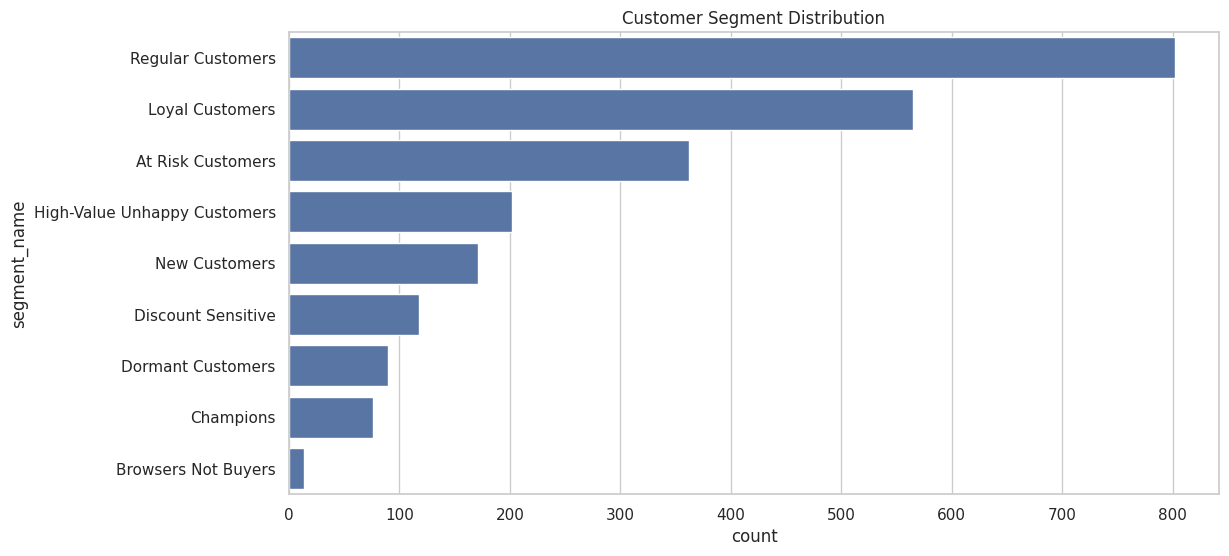

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='segment_name',
    data=segments_df,
    order=segments_df['segment_name'].value_counts().index
)

plt.title('Customer Segment Distribution')
plt.show()

In [ ]:
segments_df.groupby('segment_name')[[
    'monetary',
    'frequency',
    'recency_days',
    'ticket_count',
    'sessions_30d'
]].mean().round(2)

,monetary,frequency,recency_days,ticket_count,sessions_30d
segment_name,,,,,
At Risk Customers,2348.80,3.23,190.06,0.68,1.71
Browsers Not Buyers,785.92,1.00,71.71,0.50,17.07
Champions,4576.65,6.12,17.64,1.38,12.93
Discount Sensitive,2074.42,3.57,90.25,1.02,5.58
Dormant Customers,808.94,1.00,252.82,0.21,2.19
High-Value Unhappy Customers,5530.58,6.77,74.74,1.95,6.12
Loyal Customers,3600.63,4.75,43.08,1.01,5.85
New Customers,742.30,1.00,19.91,0.22,6.26
Regular Customers,1630.84,2.18,77.69,0.53,5.98


In [ ]:
segments_df = segments_df.merge(
    churn[['customer_id', 'churn_next_60d']],
    on='customer_id',
    how='left'
)

In [ ]:
segment_churn = segments_df.groupby('segment_name')[
    'churn_next_60d'
].mean().sort_values(ascending=False)

segment_churn

,churn_next_60d
segment_name,
Dormant Customers,0.933333
At Risk Customers,0.889503
Regular Customers,0.513716
Discount Sensitive,0.508475
Browsers Not Buyers,0.500000
High-Value Unhappy Customers,0.351485
New Customers,0.222222
Loyal Customers,0.221239
Champions,0.105263


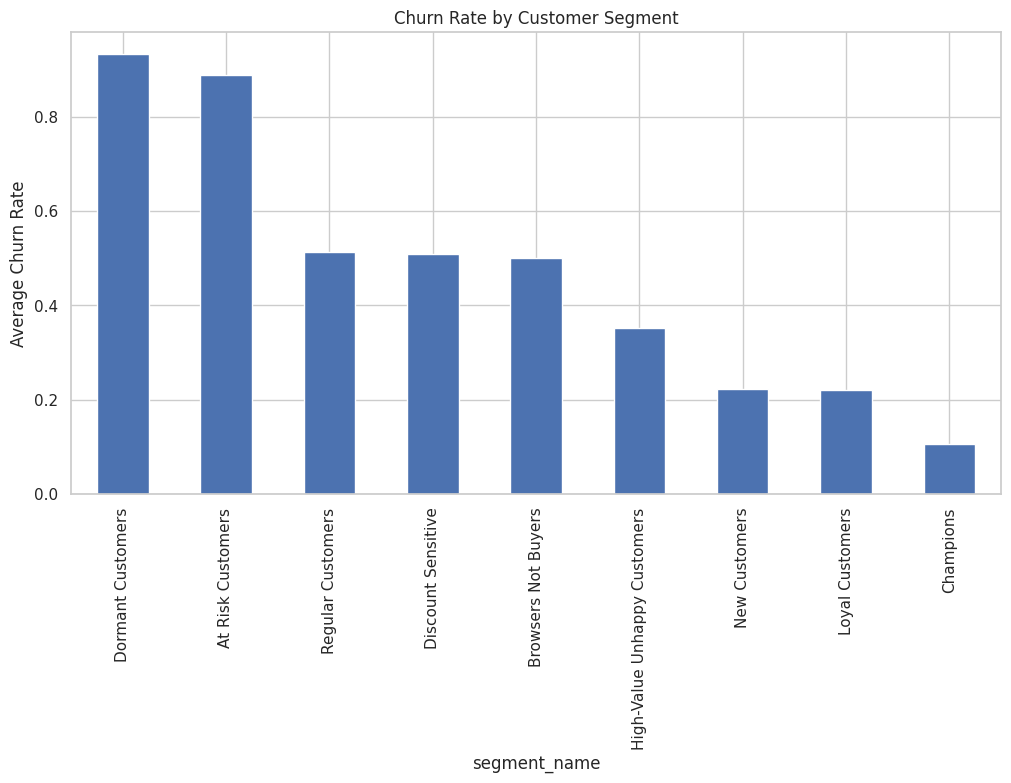

In [ ]:
plt.figure(figsize=(12,6))

segment_churn.plot(kind='bar')

plt.ylabel('Average Churn Rate')
plt.title('Churn Rate by Customer Segment')

plt.show()

In [ ]:
segments_df[['customer_id', 'segment_name']].head()

,customer_id,segment_name
0,CUST00001,Regular Customers
1,CUST00002,Regular Customers
2,CUST00003,At Risk Customers
3,CUST00004,At Risk Customers
4,CUST00005,Discount Sensitive


In [ ]:
segments_df['segment_name'].value_counts()

,count
segment_name,
Regular Customers,802
Loyal Customers,565
At Risk Customers,362
High-Value Unhappy Customers,202
New Customers,171
Discount Sensitive,118
Dormant Customers,90
Champions,76
Browsers Not Buyers,14


In [ ]:
final_segments = segments_df[[
    'customer_id',
    'segment_name',
    'recency_days',
    'frequency',
    'monetary',
    'ticket_count',
    'return_rate',
    'avg_discount_pct',
    'sessions_30d'
]]

final_segments.head()

,customer_id,segment_name,recency_days,frequency,monetary,ticket_count,return_rate,avg_discount_pct,sessions_30d
0,CUST00001,Regular Customers,107,6,2955.57,2.0,0.166667,0.363333,1
1,CUST00002,Regular Customers,40,1,581.00,1.0,0.000000,0.230000,8
2,CUST00003,At Risk Customers,171,1,649.98,0.0,0.000000,0.470000,1
3,CUST00004,At Risk Customers,131,1,1604.04,0.0,0.000000,0.160000,1
4,CUST00005,Discount Sensitive,38,4,2550.91,1.0,0.000000,0.442500,18


In [ ]:
final_segments.to_csv(
    'segments.csv',
    index=False
)

In [ ]:
segment_summary = segments_df.groupby('segment_name')[[
    'recency_days',
    'frequency',
    'monetary',
    'ticket_count',
    'return_rate',
    'sessions_30d'
]].mean().round(2)

segment_summary

,recency_days,frequency,monetary,ticket_count,return_rate,sessions_30d
segment_name,,,,,,
At Risk Customers,190.06,3.23,2348.80,0.68,0.05,1.71
Browsers Not Buyers,71.71,1.00,785.92,0.50,0.14,17.07
Champions,17.64,6.12,4576.65,1.38,0.05,12.93
Discount Sensitive,90.25,3.57,2074.42,1.02,0.06,5.58
Dormant Customers,252.82,1.00,808.94,0.21,0.06,2.19
High-Value Unhappy Customers,74.74,6.77,5530.58,1.95,0.10,6.12
Loyal Customers,43.08,4.75,3600.63,1.01,0.06,5.85
New Customers,19.91,1.00,742.30,0.22,0.06,6.26
Regular Customers,77.69,2.18,1630.84,0.53,0.08,5.98


In [ ]:
segments_df['segment_name'].value_counts()

,count
segment_name,
Regular Customers,802
Loyal Customers,565
At Risk Customers,362
High-Value Unhappy Customers,202
New Customers,171
Discount Sensitive,118
Dormant Customers,90
Champions,76
Browsers Not Buyers,14


In [ ]:
segment_summary = segments_df.groupby('segment_name')[[
    'recency_days',
    'frequency',
    'monetary',
    'ticket_count',
    'return_rate',
    'avg_discount_pct',
    'sessions_30d'
]].mean().round(2)

segment_summary

,recency_days,frequency,monetary,ticket_count,return_rate,avg_discount_pct,sessions_30d
segment_name,,,,,,,
At Risk Customers,190.06,3.23,2348.80,0.68,0.05,0.27,1.71
Browsers Not Buyers,71.71,1.00,785.92,0.50,0.14,0.28,17.07
Champions,17.64,6.12,4576.65,1.38,0.05,0.27,12.93
Discount Sensitive,90.25,3.57,2074.42,1.02,0.06,0.44,5.58
Dormant Customers,252.82,1.00,808.94,0.21,0.06,0.27,2.19
High-Value Unhappy Customers,74.74,6.77,5530.58,1.95,0.10,0.27,6.12
Loyal Customers,43.08,4.75,3600.63,1.01,0.06,0.27,5.85
New Customers,19.91,1.00,742.30,0.22,0.06,0.29,6.26
Regular Customers,77.69,2.18,1630.84,0.53,0.08,0.27,5.98


In [ ]:
segment_churn = segments_df.groupby('segment_name')[
    'churn_next_60d'
].mean().sort_values(ascending=False)

segment_churn

,churn_next_60d
segment_name,
Dormant Customers,0.933333
At Risk Customers,0.889503
Regular Customers,0.513716
Discount Sensitive,0.508475
Browsers Not Buyers,0.500000
High-Value Unhappy Customers,0.351485
New Customers,0.222222
Loyal Customers,0.221239
Champions,0.105263


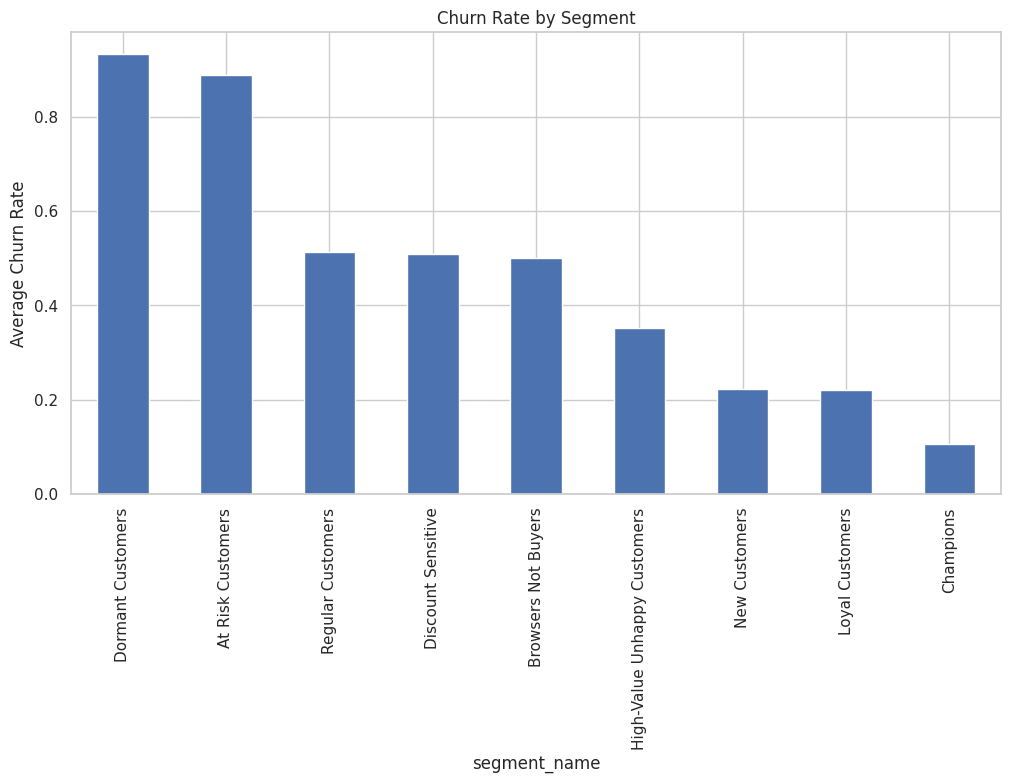

In [ ]:
plt.figure(figsize=(12,6))

segment_churn.plot(kind='bar')

plt.ylabel('Average Churn Rate')
plt.title('Churn Rate by Segment')

plt.show()

In [ ]:
final_segments = segments_df[[
    'customer_id',
    'segment_name',
    'recency_days',
    'frequency',
    'monetary',
    'ticket_count',
    'return_rate',
    'avg_discount_pct',
    'sessions_30d'
]]

final_segments.to_csv(
    'segments.csv',
    index=False
)

In [ ]:
manual_review = segments_df[
    (
        (segments_df['segment_name'] == 'High-Value Unhappy Customers') |
        (segments_df['segment_name'] == 'Browsers Not Buyers') |
        (
            (segments_df['frequency'] >= 3) &
            (segments_df['recency_days'] > 120)
        )
    )
][[
    'customer_id',
    'segment_name',
    'recency_days',
    'frequency',
    'monetary',
    'avg_sentiment',
    'sessions_30d',
    'avg_discount_pct'
]]

manual_review.head(10)

,customer_id,segment_name,recency_days,frequency,monetary,avg_sentiment,sessions_30d,avg_discount_pct
5,CUST00006,High-Value Unhappy Customers,51,5,3770.16,-0.680000,2,0.358000
16,CUST00017,At Risk Customers,286,3,1699.14,0.000000,4,0.266667
19,CUST00020,High-Value Unhappy Customers,368,3,4487.95,-0.950000,0,0.130000
24,CUST00025,Regular Customers,165,7,4868.86,-0.226667,11,0.311429
34,CUST00035,Regular Customers,127,3,1369.71,0.000000,6,0.243333
50,CUST00051,Regular Customers,210,4,4444.30,-0.385000,6,0.352500
52,CUST00053,High-Value Unhappy Customers,25,4,4192.59,-0.565000,9,0.395000
65,CUST00066,High-Value Unhappy Customers,320,5,4598.95,-1.000000,11,0.292000
67,CUST00068,Regular Customers,346,3,2123.66,-1.000000,5,0.243333
80,CUST00081,High-Value Unhappy Customers,19,8,5311.16,-0.833333,12,0.160000
